# 03b — Task 5 model selection: rolling-origin development and retrospective temporal evaluation

Notebook 03 explores the models on one random customer split. This notebook is the **model-selection protocol** for
Task 5. It answers three related, different questions, and does not declare one universal winner across them:

1. **Repurchase probability:** will an existing customer buy in the next 90 days?
2. **Conditional positive spend:** among customers who do buy, what is their mean 90-day spend?
3. **Unconditional expected spend:** P(repurchase) × conditional mean spend, evaluated on **all** eligible customers,
   including those who spend £0.

Ranking likely repurchasers is not the same as ranking customers by how much an offer would change their behaviour.
The probabilities here are predictions under the conditions observed historically (including whatever marketing the
retailer was already doing), not identified "no-offer" probabilities. Historical data identify neither campaign uplift
nor the no-offer counterfactual; that needs the Task 6 experiment.

**Run notebook 00 first.**

In [1]:
import sys, itertools, warnings
sys.path.append('../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.special import expit, logit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (brier_score_loss, log_loss, roc_auc_score, average_precision_score,
                             mean_squared_error, mean_absolute_error, median_absolute_error)

from src.features import build_customer_table, CUTOFF_DATE, TARGET_WINDOW_DAYS

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', None, 'display.width', 200)

clean = pd.read_csv('../../data/processed/invoice_lines_clean.csv', parse_dates=['InvoiceDate'])
DATA_START, DATA_END = clean['InvoiceDate'].min(), clean['InvoiceDate'].max()

CONT = ['Recency', 'TenureDays', 'CancellationRate',
        'log_Frequency', 'log_Monetary', 'log_DistinctProducts', 'log_AvgBasketValue']
BINARY = ['IsUK', 'AcquiredInQ4']
FEATURES = CONT + BINARY
TARGET_COLS = ['Repurchase', 'FutureSpend']
TABLES_DIR = '../../reports/tables'
SEED = 42
print('Data span:', DATA_START, 'to', DATA_END)

Data span: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


## D0 — Point-in-time design and data availability

For a prediction origin *t*, `src/features.py` uses half-open intervals:

* **features:** invoice lines with `InvoiceDate < t` (non-cancelled purchases for RFM; all invoices for cancellation rate);
* **targets:** non-cancelled invoice lines with `t ≤ InvoiceDate < t + 90 days`.

A customer is **eligible** at *t* if they have at least one non-cancelled, identified purchase before *t*. New customers
first seen after *t* are outside the population by design: this is a model for **existing** customers.

**Origins.** Origins are spaced exactly 90 days apart, counting back from the 9 Sep 2011 cutoff, so that every training
snapshot's labels are complete by the next origin, when the model would be used. The earliest origin keeps at least six
months of feature history (data start 1 Dec 2009). Five 90-day steps give six origins:

| Role | Train on origin | Predict at origin | Outcome window predicted |
|---|---|---|---|
| Development period 1 | 16 Jun 2010 | 14 Sep 2010 | Sep–Dec 2010 (pre-Christmas) |
| Development period 2 | 14 Sep 2010 | 13 Dec 2010 | Dec 2010–Mar 2011 |
| Development period 3 | 13 Dec 2010 | 13 Mar 2011 | Mar–Jun 2011 |
| Development period 4 | 13 Mar 2011 | 11 Jun 2011 | Jun–Sep 2011 |
| Retrospective temporal evaluation | 11 Jun 2011 | 9 Sep 2011 | Sep–Dec 2011 |

Each step trains on the most recent snapshot whose labels are complete and predicts the next one — the same procedure
the retailer would follow. The four development periods cover each season once, which is why they are **weighted
equally** when aggregating.

**Prior exposure — stated honestly.** The Sep–Dec 2011 outcomes have already been examined in notebooks 03 and 05 and
in earlier versions of this analysis. Rerunning a notebook cannot make them an untouched test set. The final evaluation
below is therefore a **retrospective temporal evaluation** of a model locked on development data only; it is not a
historically blind test. No genuinely unexamined later data exist in this dataset.

**Repeated customers.** The same customer appears in several snapshots with different, time-stamped features. A customer
in a training snapshot and a later evaluation snapshot is not leakage for this use case — the model is meant to score
*returning* customers whose earlier behaviour it has seen — but rows are not independent, so all bootstrap uncertainty
that pools periods resamples **customers**, not rows. `CustomerID` is never a predictor.

In [2]:
STEP = pd.Timedelta(days=TARGET_WINDOW_DAYS)
FINAL_ORIGIN = pd.Timestamp(CUTOFF_DATE)
ORIGINS = [FINAL_ORIGIN - k * STEP for k in range(5, -1, -1)]
DEV_FOLDS = [(ORIGINS[i], ORIGINS[i + 1]) for i in range(4)]
FINAL_FOLD = (ORIGINS[4], ORIGINS[5])

def add_logs(d):
    d = d.copy()
    for col in ['Frequency', 'Monetary', 'DistinctProducts', 'AvgBasketValue']:
        d[f'log_{col}'] = np.log1p(d[col])
    return d

snap = {}
rows = []
for t in ORIGINS:
    assert t + STEP <= DATA_END, f'incomplete outcome window for origin {t}'
    tab = add_logs(build_customer_table(clean, cutoff=t))
    assert tab['CustomerID'].is_unique and tab[FEATURES].notna().all().all()
    assert not set(TARGET_COLS + ['CustomerID']) & set(FEATURES)
    assert (tab.loc[tab['Repurchase'] == 1, 'FutureSpend'] > 0).all()
    snap[t] = tab
    rows.append({'origin t': t.date(), 'features from': DATA_START.date(), 'targets [t, t+90d)': f'{t.date()} to {(t + STEP).date()}',
                 'eligible customers': len(tab), 'prevalence': round(tab['Repurchase'].mean(), 3),
                 'repurchasers': int(tab['Repurchase'].sum()), 'mean FutureSpend (all)': round(tab['FutureSpend'].mean(), 1),
                 'median tenure (days)': tab['TenureDays'].median()})
snapshots = pd.DataFrame(rows)
snapshots['role'] = ['train only (dev 1)', 'dev 1 eval / dev 2 train', 'dev 2 eval / dev 3 train',
                     'dev 3 eval / dev 4 train', 'dev 4 eval / final train', 'retrospective temporal evaluation']
assert len(snap[FINAL_ORIGIN]) == len(pd.read_csv('../../data/processed/customer_table.csv'))
print('Outcome windows fully covered; no target or ID columns among predictors.')
snapshots

Outcome windows fully covered; no target or ID columns among predictors.


,origin t,features from,"targets [t, t+90d)",eligible customers,prevalence,repurchasers,mean FutureSpend (all),median tenure (days),role
0,2010-06-16,2009-12-01,2010-06-16 to 2010-09-14,2832,0.476,1349,518.4,127.0,train only (dev 1)
1,2010-09-14,2009-12-01,2010-09-14 to 2010-12-13,3364,0.575,1934,735.7,197.0,dev 1 eval / dev 2 train
2,2010-12-13,2009-12-01,2010-12-13 to 2011-03-13,4292,0.304,1306,279.2,255.0,dev 2 eval / dev 3 train
3,2011-03-13,2009-12-01,2011-03-13 to 2011-06-11,4581,0.353,1616,332.8,327.0,dev 3 eval / dev 4 train
4,2011-06-11,2009-12-01,2011-06-11 to 2011-09-09,4951,0.320,1586,333.9,399.0,dev 4 eval / final train
5,2011-09-09,2009-12-01,2011-09-09 to 2011-12-08,5253,0.434,2278,530.3,472.0,retrospective temporal evaluation


## D1 — Candidates, metrics and the selection rule (declared before any results)

**Candidates (probability models), all on the same nine predictors.** Continuous predictors are standardised inside each
training snapshot; for the penalised models the scaler sits **inside** the tuning pipeline, so it is refitted within
every inner cross-validation fold.

| Candidate | Fitting inside each training snapshot |
|---|---|
| Full logistic | Unpenalised maximum likelihood |
| Forward selection, backward selection, best subset | Subset chosen by AIC (statsmodels Logit), **re-run in every training snapshot**; AIC is only used *within* a family, never to compare families |
| Ridge, LASSO, elastic net | `GridSearchCV` over a scaler + logistic pipeline, inner 5-fold stratified CV (shuffled, seed 42), scored by **Brier**; C on 20 log-spaced values in [1e-4, 1e4]; elastic-net mixing in {0.1, 0.3, 0.5, 0.7, 0.9} |

**Baselines (comparators, not eligible for selection).** *Constant:* the training snapshot's repurchase rate.
*Recency rank:* score = −Recency; it has no probability scale, so Brier, log-loss and calibration are N/A.

**Metrics** (identical evaluation customers for every candidate):

| Metric | Role | Better |
|---|---|---|
| **Brier score** | **Primary** — probabilities feed the two-part expected-spend calculation | Lower |
| Log-loss (probabilities clipped to [1e-15, 1−1e-15]) | Secondary probability score; punishes confident errors | Lower |
| ROC-AUC | Ranking across all thresholds | Higher |
| Average precision (AP, `average_precision_score`) | Precision–recall summary; depends on prevalence | Higher |
| Calibration intercept / slope | Logistic regression of the outcome on the predicted log-odds (p clipped to [1e-6, 1−1e-6]), intercept and slope estimated jointly | ≈ 0 / ≈ 1 |
| Precision@10%, Lift@10% | Repurchase rate among the top k = ceil(0.10 n) scores (ties broken by ascending CustomerID); lift = precision ÷ prevalence. 10% is the project's illustrative contact capacity, not a client budget | Higher |
| Predictors | Non-zero coefficients excluding the intercept; penalised coefficients count as zero if |β| ≤ 1e-6 | Fewer when comparable |

Brier and log-loss measure overall probabilistic accuracy (calibration and discrimination together), not calibration
alone. AP and precision depend on prevalence, which differs by period, so differences across periods are not pure changes
in model quality. Accuracy, F1, a 0.5 threshold and scenario profit are **not** used for selection: there is no fixed
operational classification decision, and profit depends on an unmeasured uplift.

**Selection rule (fixed before the development results are computed):**

1. Exclude any candidate with a non-converged fit or non-finite / out-of-range predictions in any development period, and
   report it.
2. Select the candidate with the smallest **unrounded mean development Brier score**, equal weight per development period.
3. Exact numerical ties only: fewer mean retained predictors, then lower mean development log-loss, then the order
   full logistic, forward, backward, best subset, Ridge, LASSO, elastic net.
4. Report paired, customer-clustered bootstrap uncertainty for the differences. The winner is "selected under the Brier
   rule", not "best".
5. The selected model is then **locked** (family and tuning procedure) and refitted on the final training snapshot. Its
   retrospective temporal evaluation is reported as is; no reselection is made from it.

In [3]:
CANDIDATES = ['Full logistic', 'Forward selection', 'Backward selection', 'Best subset', 'Ridge', 'LASSO', 'Elastic net']
BASELINES = ['Constant (training rate)', 'Recency rank']
C_GRID = np.logspace(-4, 4, 20)
COEF_TOL = 1e-6
MAX_ITER = 20000

def make_prep():
    return ColumnTransformer([('num', StandardScaler(), CONT)], remainder='passthrough', verbose_feature_names_out=False)

class SMLogit:
    # statsmodels logit on a chosen subset, with a scaler fitted on the training snapshot
    def __init__(self, feats, scaler, res):
        self.feats, self.scaler, self.res = feats, scaler, res
    def X(self, d):
        X = d[FEATURES].copy(); X[CONT] = self.scaler.transform(d[CONT])
        return sm.add_constant(X[self.feats], has_constant='add')
    def predict(self, d):
        return np.asarray(self.res.predict(self.X(d)))
    def coefs(self):
        return self.res.params.drop('const').reindex(FEATURES).fillna(0.0)

def aic_fit(Xs, y, feats):
    X = sm.add_constant(Xs[feats], has_constant='add') if feats else np.ones((len(Xs), 1))
    return sm.Logit(y, X).fit(disp=0, maxiter=200)

def forward(Xs, y):
    sel, best = [], aic_fit(Xs, y, []).aic
    while True:
        trials = {f: aic_fit(Xs, y, sel + [f]).aic for f in FEATURES if f not in sel}
        if not trials: break
        f, a = min(trials.items(), key=lambda kv: kv[1])
        if a < best - 1e-9: sel.append(f); best = a
        else: break
    return sel

def backward(Xs, y):
    sel = list(FEATURES); best = aic_fit(Xs, y, sel).aic
    while len(sel) > 1:
        trials = {f: aic_fit(Xs, y, [g for g in sel if g != f]).aic for f in sel}
        f, a = min(trials.items(), key=lambda kv: kv[1])
        if a < best - 1e-9: sel.remove(f); best = a
        else: break
    return sel

def best_subset(Xs, y):
    best, feats = np.inf, None
    for k in range(1, len(FEATURES) + 1):
        for combo in itertools.combinations(FEATURES, k):
            a = aic_fit(Xs, y, list(combo)).aic
            if a < best: best, feats = a, list(combo)
    return feats

class SKModel:
    def __init__(self, est, tuned=None):
        self.est, self.tuned = est, tuned or {}
    def predict(self, d):
        return self.est.predict_proba(d[FEATURES])[:, 1]
    def coefs(self):
        return pd.Series(self.est[-1].coef_.ravel(), index=FEATURES)
    def converged(self):
        return bool(np.all(self.est[-1].n_iter_ < MAX_ITER))

def tune(l1_ratios, solver, X, y):
    pipe = Pipeline([('prep', make_prep()), ('clf', LogisticRegression(solver=solver, max_iter=MAX_ITER, random_state=SEED))])
    grid = {'clf__C': C_GRID, 'clf__l1_ratio': l1_ratios}
    gs = GridSearchCV(pipe, grid, scoring='neg_brier_score',
                      cv=StratifiedKFold(5, shuffle=True, random_state=SEED), n_jobs=-1, refit=True)
    gs.fit(X, y)
    return SKModel(gs.best_estimator_, {k.replace('clf__', ''): v for k, v in gs.best_params_.items()})

def fit_candidates(train):
    X, y = train[FEATURES], train['Repurchase'].values
    out = {}
    scaler = StandardScaler().fit(train[CONT])
    Xs = X.copy(); Xs[CONT] = scaler.transform(train[CONT])
    full = Pipeline([('prep', make_prep()), ('clf', LogisticRegression(C=np.inf, max_iter=MAX_ITER, random_state=SEED))]).fit(X, y)
    out['Full logistic'] = SKModel(full)
    for name, selector in [('Forward selection', forward), ('Backward selection', backward), ('Best subset', best_subset)]:
        feats = selector(Xs, y)
        out[name] = SMLogit(feats, scaler, aic_fit(Xs, y, feats))
    out['Ridge'] = tune([0.0], 'lbfgs', X, y)
    out['LASSO'] = tune([1.0], 'saga', X, y)
    out['Elastic net'] = tune([0.1, 0.3, 0.5, 0.7, 0.9], 'saga', X, y)
    return out

def status_of(m, p):
    conv = m.converged() if isinstance(m, SKModel) else bool(m.res.mle_retvals['converged'])
    ok_pred = np.all(np.isfinite(p)) and np.all((p >= 0) & (p <= 1))
    return 'ok' if (conv and ok_pred) else ('not converged' if not conv else 'invalid predictions')

def n_predictors(m):
    return int((m.coefs().abs() > COEF_TOL).sum())

In [4]:
def top_k_order(score, ids):
    # descending score; ties broken by ascending CustomerID (independent of the outcome)
    return np.lexsort((ids, -np.asarray(score)))

def precision_at(y, score, ids, frac=0.10):
    k = int(np.ceil(frac * len(y)))
    return y[top_k_order(score, ids)[:k]].mean()

def calibration_int_slope(y, p):
    lp = logit(np.clip(p, 1e-6, 1 - 1e-6))
    try:
        res = sm.Logit(y, sm.add_constant(lp)).fit(disp=0, maxiter=200)
        if not res.mle_retvals['converged']:
            return np.nan, np.nan
        return float(res.params[0]), float(res.params[1])
    except Exception:
        return np.nan, np.nan

def class_metrics(y, score, ids, is_prob=True):
    y = np.asarray(y); score = np.asarray(score, dtype=float)
    prev = y.mean()
    m = {'n': len(y), 'prevalence': prev,
         'ROC-AUC': roc_auc_score(y, score), 'AP': average_precision_score(y, score),
         'Precision@10%': precision_at(y, score, ids)}
    m['Lift@10%'] = m['Precision@10%'] / prev
    for f in (0.05, 0.20):
        m[f'Precision@{int(f * 100)}%'] = precision_at(y, score, ids, f)
    if is_prob:
        a, b = calibration_int_slope(y, score)
        m.update({'Brier': brier_score_loss(y, score),
                  'Log-loss': log_loss(y, np.clip(score, 1e-15, 1 - 1e-15), labels=[0, 1]),
                  'Cal. intercept': a, 'Cal. slope': b, 'Mean predicted': score.mean()})
    else:
        m.update({'Brier': np.nan, 'Log-loss': np.nan, 'Cal. intercept': np.nan, 'Cal. slope': np.nan,
                  'Mean predicted': np.nan})
    return m

## D2 — Development: rolling-origin fits and validation predictions

Every candidate is fitted on each development training snapshot and scored on the next snapshot. All tuning and subset
selection happen inside the training snapshot only.

In [5]:
dev_pred, dev_status, dev_coefs, dev_tuned = [], [], [], []
fitted_dev = {}
for fold, (t_tr, t_va) in enumerate(DEV_FOLDS, start=1):
    train, valid = snap[t_tr], snap[t_va]
    models = fit_candidates(train)
    fitted_dev[fold] = models
    base = {'Constant (training rate)': np.full(len(valid), train['Repurchase'].mean()),
            'Recency rank': -valid['Recency'].values}
    for name, m in models.items():
        p = m.predict(valid)
        dev_status.append({'fold': fold, 'candidate': name, 'status': status_of(m, p), 'predictors': n_predictors(m)})
        dev_coefs.append(m.coefs().rename((fold, name)))
        if isinstance(m, SKModel) and m.tuned:
            dev_tuned.append({'fold': fold, 'candidate': name, **m.tuned})
        dev_pred.append(pd.DataFrame({'fold': fold, 'CustomerID': valid['CustomerID'].values,
                                      'y': valid['Repurchase'].values, 'candidate': name, 'score': p}))
    for name, s in base.items():
        dev_pred.append(pd.DataFrame({'fold': fold, 'CustomerID': valid['CustomerID'].values,
                                      'y': valid['Repurchase'].values, 'candidate': name, 'score': s}))
    print(f'Dev period {fold}: trained on {t_tr.date()} (n={len(train)}), validated on {t_va.date()} (n={len(valid)})')

dev_pred = pd.concat(dev_pred, ignore_index=True)
dev_status = pd.DataFrame(dev_status)
print('\nFit status by candidate (all development periods):')
print(dev_status.pivot(index='candidate', columns='fold', values='status'))
print('\nTuned hyper-parameters (inner CV on the training snapshot, Brier):')
pd.DataFrame(dev_tuned).round(4)

Dev period 1: trained on 2010-06-16 (n=2832), validated on 2010-09-14 (n=3364)


Dev period 2: trained on 2010-09-14 (n=3364), validated on 2010-12-13 (n=4292)


Dev period 3: trained on 2010-12-13 (n=4292), validated on 2011-03-13 (n=4581)


Dev period 4: trained on 2011-03-13 (n=4581), validated on 2011-06-11 (n=4951)

Fit status by candidate (all development periods):
fold                 1   2   3   4
candidate                         
Backward selection  ok  ok  ok  ok
Best subset         ok  ok  ok  ok
Elastic net         ok  ok  ok  ok
Forward selection   ok  ok  ok  ok
Full logistic       ok  ok  ok  ok
LASSO               ok  ok  ok  ok
Ridge               ok  ok  ok  ok

Tuned hyper-parameters (inner CV on the training snapshot, Brier):


,fold,candidate,C,l1_ratio
0,1,Ridge,0.0336,0.0
1,1,LASSO,0.0886,1.0
2,1,Elastic net,0.0886,0.9
3,2,Ridge,0.0127,0.0
4,2,LASSO,0.0886,1.0
5,2,Elastic net,0.0127,0.1
6,3,Ridge,0.6158,0.0
7,3,LASSO,0.6158,1.0
8,3,Elastic net,0.6158,0.9
9,4,Ridge,4.2813,0.0


In [6]:
per_fold = []
for (fold, name), g in dev_pred.groupby(['fold', 'candidate'], sort=False):
    m = class_metrics(g['y'].values, g['score'].values, g['CustomerID'].values, is_prob=(name != 'Recency rank'))
    per_fold.append({'fold': fold, 'candidate': name, **m})
per_fold = pd.DataFrame(per_fold)

pred_counts = dev_status.groupby('candidate')['predictors'].mean()
valid_cands = [c for c in CANDIDATES if (dev_status.query('candidate == @c')['status'] == 'ok').all()]
excluded = [c for c in CANDIDATES if c not in valid_cands]
print('Excluded by rule step 1:', excluded or 'none')

agg_cols = ['Brier', 'Log-loss', 'ROC-AUC', 'AP', 'Cal. intercept', 'Cal. slope', 'Precision@10%', 'Lift@10%',
            'Precision@5%', 'Precision@20%', 'Mean predicted', 'prevalence']
dev_table = per_fold.groupby('candidate', sort=False)[agg_cols].mean()          # equal weight per period
dev_table.insert(0, 'Predictors (mean)', pred_counts.reindex(dev_table.index))
for f in range(1, 5):
    dev_table[f'Brier P{f}'] = per_fold.query('fold == @f').set_index('candidate')['Brier']

# --- Selection rule, exactly as declared in D1 ---
order = {c: i for i, c in enumerate(CANDIDATES)}
ranked = sorted(valid_cands, key=lambda c: (dev_table.loc[c, 'Brier'], dev_table.loc[c, 'Predictors (mean)'],
                                            dev_table.loc[c, 'Log-loss'], order[c]))
SELECTED = ranked[0]
print('Unrounded mean development Brier:')
for c in ranked:
    print(f'  {c:20s} {dev_table.loc[c, "Brier"]:.8f}')
print(f'\nSELECTED UNDER THE BRIER RULE: {SELECTED}')

Excluded by rule step 1: none
Unrounded mean development Brier:
  LASSO                0.20264679
  Ridge                0.20265961
  Elastic net          0.20279048
  Forward selection    0.20299339
  Backward selection   0.20301502
  Best subset          0.20301502
  Full logistic        0.20315918

SELECTED UNDER THE BRIER RULE: LASSO


### Development uncertainty (paired, clustered by customer)

Customers appear in several development periods, so the bootstrap resamples **customer IDs** (with replacement, 2,000
replicates, seed 42) and carries every row of a sampled customer, in every period, into the replicate. In each replicate
the per-period Brier scores are recomputed and averaged with equal weight, and the difference *candidate − selected* is
taken on the same resampled customers. Brier is a mean of per-customer losses, so it is well defined in every replicate.
This interval reflects resampling of customers within these four periods; it does not cover tuning variability or future
drift.

In [7]:
B = 2000
rng = np.random.default_rng(SEED)
prob_cands = CANDIDATES + ['Constant (training rate)']
wide = dev_pred[dev_pred['candidate'].isin(prob_cands)].pivot_table(
    index=['fold', 'CustomerID'], columns='candidate', values='score').reset_index()
yv = dev_pred.drop_duplicates(['fold', 'CustomerID']).set_index(['fold', 'CustomerID'])['y']
wide['y'] = yv.loc[list(zip(wide['fold'], wide['CustomerID']))].values
sq = {c: (wide[c].values - wide['y'].values) ** 2 for c in prob_cands}
ids = wide['CustomerID'].values
uid, inv = np.unique(ids, return_inverse=True)
folds = wide['fold'].values

def weighted_dev_brier(weights):
    out = {}
    for c in prob_cands:
        per = [np.sum(weights[folds == f] * sq[c][folds == f]) / np.sum(weights[folds == f]) for f in range(1, 5)]
        out[c] = np.mean(per)
    return out

diffs = {c: [] for c in prob_cands if c != SELECTED}
for _ in range(B):
    w_id = rng.multinomial(len(uid), np.full(len(uid), 1 / len(uid)))
    w = w_id[inv].astype(float)
    bri = weighted_dev_brier(w)
    for c in diffs:
        diffs[c].append(bri[c] - bri[SELECTED])
point = weighted_dev_brier(np.ones(len(ids)))
dev_unc = pd.DataFrame({c: {'Brier difference vs selected': point[c] - point[SELECTED],
                            '95% CI low': np.percentile(v, 2.5), '95% CI high': np.percentile(v, 97.5),
                            'share of replicates where selected is better': np.mean(np.array(v) > 0)}
                        for c, v in diffs.items()}).T
print(f'{B} customer-clustered bootstrap replicates over {len(uid)} distinct customers; positive = selected has lower Brier')
dev_unc.round(5)

2000 customer-clustered bootstrap replicates over 4951 distinct customers; positive = selected has lower Brier


,Brier difference vs selected,95% CI low,95% CI high,share of replicates where selected is better
Full logistic,0.00051,0.00024,0.00079,1.0000
Forward selection,0.00035,0.00009,0.00061,0.9960
Backward selection,0.00037,0.00011,0.00064,0.9990
Best subset,0.00037,0.00011,0.00064,0.9990
Ridge,0.00001,-0.00014,0.00016,0.5595
Elastic net,0.00014,0.00005,0.00023,0.9990
Constant (training rate),0.04447,0.04044,0.04877,1.0000


In [8]:
full_dev = dev_table.copy()
full_dev = full_dev.join(dev_unc[['Brier difference vs selected', '95% CI low', '95% CI high']], how='left')
full_dev.loc[SELECTED, ['Brier difference vs selected', '95% CI low', '95% CI high']] = 0.0
full_dev = full_dev.reindex(CANDIDATES + BASELINES)

def verdict(c):
    if c == SELECTED:
        return 'Selected under the Brier rule'
    if c in BASELINES:
        return 'Baseline (not eligible)'
    if c in excluded:
        return 'Excluded: ' + ', '.join(dev_status.query('candidate == @c and status != "ok"')['status'].unique())
    lo, hi = dev_unc.loc[c, '95% CI low'], dev_unc.loc[c, '95% CI high']
    return ('Indistinguishable from selected (CI includes 0)' if lo <= 0 <= hi
            else 'Worse than selected (CI above 0)' if lo > 0 else 'Better than selected (CI below 0)')
full_dev['Verdict'] = [verdict(c) for c in full_dev.index]

compact = pd.DataFrame({
    'Predictors': full_dev['Predictors (mean)'].round(1),
    'Brier ↓': full_dev['Brier'].round(4),
    'ROC-AUC ↑': full_dev['ROC-AUC'].round(3),
    'AP ↑': full_dev['AP'].round(3),
    'Cal. intercept / slope': [('N/A' if np.isnan(a) else f'{a:+.2f} / {b:.2f}')
                               for a, b in zip(full_dev['Cal. intercept'], full_dev['Cal. slope'])],
    'Precision@10% ↑': full_dev['Precision@10%'].round(3),
    'Lift@10% ↑': full_dev['Lift@10%'].round(2),
    'Verdict and evidence': full_dev['Verdict'],
})
compact.index.name = 'Model'
print('DEVELOPMENT — USED FOR SELECTION. Four rolling-origin periods (validation origins 14 Sep 2010, 13 Dec 2010, '
      '13 Mar 2011, 11 Jun 2011), equal weight; metric values are period means.')
print(snapshots.iloc[1:5][['origin t', 'eligible customers', 'prevalence']].to_string(index=False))
compact

DEVELOPMENT — USED FOR SELECTION. Four rolling-origin periods (validation origins 14 Sep 2010, 13 Dec 2010, 13 Mar 2011, 11 Jun 2011), equal weight; metric values are period means.
  origin t  eligible customers  prevalence
2010-09-14                3364       0.575
2010-12-13                4292       0.304
2011-03-13                4581       0.353
2011-06-11                4951       0.320


,Predictors,Brier ↓,ROC-AUC ↑,AP ↑,Cal. intercept / slope,Precision@10% ↑,Lift@10% ↑,Verdict and evidence
Model,,,,,,,,
Full logistic,9.0,0.2032,0.778,0.712,-0.31 / 0.92,0.864,2.35,Worse than selected (CI above 0)
Forward selection,5.5,0.2030,0.779,0.713,-0.30 / 0.95,0.862,2.34,Worse than selected (CI above 0)
Backward selection,5.5,0.2030,0.779,0.713,-0.30 / 0.95,0.862,2.34,Worse than selected (CI above 0)
Best subset,5.5,0.2030,0.779,0.713,-0.30 / 0.95,0.862,2.34,Worse than selected (CI above 0)
Ridge,9.0,0.2027,0.778,0.713,-0.31 / 0.96,0.864,2.35,Indistinguishable from selected (CI includes 0)
LASSO,7.2,0.2026,0.779,0.713,-0.30 / 0.96,0.864,2.35,Selected under the Brier rule
Elastic net,7.5,0.2028,0.778,0.713,-0.30 / 0.97,0.863,2.34,Worse than selected (CI above 0)
Constant (training rate),NaN,0.2471,0.500,0.388,N/A,0.414,1.08,Baseline (not eligible)
Recency rank,NaN,NaN,0.719,0.587,N/A,0.670,1.81,Baseline (not eligible)


In [9]:
# Coefficient stability across the four development fits (standardised coefficients)
coef_df = pd.concat(dev_coefs, axis=1).T
coef_df.index = pd.MultiIndex.from_tuples(coef_df.index, names=['fold', 'candidate'])
stab = []
for c in CANDIDATES:
    cf = coef_df.xs(c, level='candidate')
    nz = cf.abs() > COEF_TOL
    sign = np.sign(cf.where(nz))
    stab.append(pd.DataFrame({'candidate': c, 'feature': FEATURES,
                              'selected in folds': nz.sum().values,
                              'sign-consistent when selected': [(sign[f].dropna().nunique() <= 1) for f in FEATURES],
                              'median coef': cf.median().values}))
stab = pd.concat(stab)
print(f'{SELECTED}: selection frequency (out of 4 development fits) and sign stability')
stab.query('candidate == @SELECTED').drop(columns='candidate').round(3)

LASSO: selection frequency (out of 4 development fits) and sign stability


,feature,selected in folds,sign-consistent when selected,median coef
0,Recency,4,True,-0.239
1,TenureDays,3,False,-0.073
2,CancellationRate,4,True,0.048
3,log_Frequency,4,True,0.821
4,log_Monetary,4,False,0.221
5,log_DistinctProducts,4,False,0.027
6,log_AvgBasketValue,1,True,0.000
7,IsUK,2,True,-0.010
8,AcquiredInQ4,3,False,0.095


## D3 — Retrospective temporal evaluation of the locked probability model

The selected family and its tuning procedure are refitted on the 11 Jun 2011 snapshot (labels complete on 9 Sep 2011)
and evaluated on the 9 Sep 2011 customers. **Prespecified benchmarks:** the constant training rate, the recency rank and
the full logistic model. The other candidates are shown for description only; nothing is reselected from this table.

In [10]:
t_tr, t_ev = FINAL_FOLD
train_f, evalf = snap[t_tr], snap[t_ev]
final_models = fit_candidates(train_f)
y_ev, ids_ev = evalf['Repurchase'].values, evalf['CustomerID'].values
final_scores = {name: m.predict(evalf) for name, m in final_models.items()}
final_scores['Constant (training rate)'] = np.full(len(evalf), train_f['Repurchase'].mean())
final_scores['Recency rank'] = -evalf['Recency'].values
final_status = {name: status_of(m, final_scores[name]) for name, m in final_models.items()}
print('Final fit status:', final_status)
if isinstance(final_models[SELECTED], SKModel):
    print('Locked model tuned parameters on the final training snapshot:', final_models[SELECTED].tuned)

final_rows = {}
for name, s in final_scores.items():
    final_rows[name] = class_metrics(y_ev, s, ids_ev, is_prob=(name != 'Recency rank'))
final_tab = pd.DataFrame(final_rows).T
final_tab.insert(0, 'Predictors', [n_predictors(final_models[n]) if n in final_models else np.nan for n in final_tab.index])
role = {SELECTED: 'LOCKED (selected on development)', 'Constant (training rate)': 'Prespecified benchmark',
        'Recency rank': 'Prespecified benchmark', 'Full logistic': 'Prespecified benchmark'}
final_tab.insert(0, 'Role', [role.get(n, 'Descriptive only') for n in final_tab.index])
final_tab = final_tab.loc[[SELECTED] + [n for n in final_tab.index if n != SELECTED]]
print(f'RETROSPECTIVE TEMPORAL EVALUATION: trained {t_tr.date()} (n={len(train_f)}, prevalence {train_f["Repurchase"].mean():.3f}), '
      f'evaluated {t_ev.date()} (n={len(evalf)}, prevalence {y_ev.mean():.3f})')
final_tab[['Role', 'Predictors', 'Brier', 'Log-loss', 'ROC-AUC', 'AP', 'Cal. intercept', 'Cal. slope',
           'Precision@10%', 'Lift@10%', 'Mean predicted', 'prevalence']].round(4)

Final fit status: {'Full logistic': 'ok', 'Forward selection': 'ok', 'Backward selection': 'ok', 'Best subset': 'ok', 'Ridge': 'ok', 'LASSO': 'ok', 'Elastic net': 'ok'}
Locked model tuned parameters on the final training snapshot: {'C': np.float64(0.08858667904100823), 'l1_ratio': 1.0}
RETROSPECTIVE TEMPORAL EVALUATION: trained 2011-06-11 (n=4951, prevalence 0.320), evaluated 2011-09-09 (n=5253, prevalence 0.434)


,Role,Predictors,Brier,Log-loss,ROC-AUC,AP,Cal. intercept,Cal. slope,Precision@10%,Lift@10%,Mean predicted,prevalence
LASSO,LOCKED (selected on development),5.0,0.2005,0.6082,0.7914,0.7579,0.6288,0.7866,0.8992,2.0736,0.3013,0.4337
Full logistic,Prespecified benchmark,9.0,0.2014,0.6118,0.7894,0.7558,0.6034,0.7601,0.8954,2.0649,0.3024,0.4337
Forward selection,Descriptive only,6.0,0.2016,0.6122,0.7893,0.7554,0.6038,0.7594,0.8954,2.0649,0.3021,0.4337
Backward selection,Descriptive only,6.0,0.2016,0.6122,0.7893,0.7554,0.6038,0.7594,0.8954,2.0649,0.3021,0.4337
Best subset,Descriptive only,6.0,0.2016,0.6122,0.7893,0.7554,0.6038,0.7594,0.8954,2.0649,0.3021,0.4337
Ridge,Descriptive only,9.0,0.2014,0.6118,0.7894,0.7558,0.6034,0.7601,0.8954,2.0649,0.3024,0.4337
Elastic net,Descriptive only,6.0,0.2006,0.6085,0.7914,0.7580,0.6291,0.7853,0.9011,2.0780,0.3011,0.4337
Constant (training rate),Prespecified benchmark,NaN,0.2584,0.7124,0.5000,0.4337,NaN,NaN,0.4620,1.0653,0.3203,0.4337
Recency rank,Prespecified benchmark,NaN,NaN,NaN,0.7616,0.6812,NaN,NaN,0.7681,1.7711,NaN,0.4337


In [11]:
# Paired customer-level bootstrap on the evaluation customers (one row per customer, so customer = row)
rng = np.random.default_rng(SEED)
B = 2000
bench = [b for b in ['Full logistic', 'Constant (training rate)', 'Recency rank'] if b != SELECTED]
stats = {b: {k: [] for k in ['Brier', 'Log-loss', 'ROC-AUC', 'AP', 'Precision@10%']} for b in bench}
skipped = 0
n = len(y_ev)
for _ in range(B):
    i = rng.integers(0, n, n)
    yb = y_ev[i]
    if yb.min() == yb.max():
        skipped += 1; continue
    ms = class_metrics(yb, final_scores[SELECTED][i], ids_ev[i])
    for b in bench:
        mb = class_metrics(yb, final_scores[b][i], ids_ev[i], is_prob=(b != 'Recency rank'))
        for k in stats[b]:
            stats[b][k].append(ms[k] - mb[k])
rows = []
for b in bench:
    for k, v in stats[b].items():
        v = np.array(v, dtype=float)
        if np.all(np.isnan(v)):
            continue
        point = final_tab.loc[SELECTED, k] - final_tab.loc[b, k]
        rows.append({'benchmark': b, 'metric': k, f'{SELECTED} − benchmark': point,
                     '95% CI low': np.nanpercentile(v, 2.5), '95% CI high': np.nanpercentile(v, 97.5)})
final_unc = pd.DataFrame(rows)
print(f'{B} paired bootstrap replicates; {skipped} skipped for having one outcome class. '
      'Brier/log-loss: negative favours the locked model; AUC/AP/precision: positive favours it.')
final_unc.round(4)

2000 paired bootstrap replicates; 0 skipped for having one outcome class. Brier/log-loss: negative favours the locked model; AUC/AP/precision: positive favours it.


,benchmark,metric,LASSO − benchmark,95% CI low,95% CI high
0,Full logistic,Brier,-0.0009,-0.0012,-0.0005
1,Full logistic,Log-loss,-0.0036,-0.0048,-0.0024
2,Full logistic,ROC-AUC,0.0020,0.0012,0.0027
3,Full logistic,AP,0.0022,0.0014,0.0031
4,Full logistic,Precision@10%,0.0038,-0.0038,0.0114
5,Constant (training rate),Brier,-0.0579,-0.0637,-0.0521
6,Constant (training rate),Log-loss,-0.1042,-0.1205,-0.0869
7,Constant (training rate),ROC-AUC,0.2914,0.2793,0.3034
8,Constant (training rate),AP,0.3243,0.3092,0.3397
9,Constant (training rate),Precision@10%,0.4373,0.3935,0.4924


### Temporal calibration, and an assessed recalibration policy

Calibration is shown for every development period and the retrospective evaluation. Because the probability *level*
shifted between seasons in notebook 03 (A8), one recalibration policy is **assessed**: an intercept-only shift, learned on
the selected model's **development period 4** predictions (the most recent period whose outcomes are known before
9 Sep 2011) with the slope fixed at 1, then frozen and applied to the locked model's evaluation predictions. It is learned
on development data only. The uncorrected locked model remains the primary result.

Intercept shift learned on development period 4: -0.131 on the log-odds scale


,period,mean predicted,prevalence,cal. intercept,cal. slope
0,Dev 1: 2010-09-14,0.487,0.575,0.398,0.769
1,Dev 2: 2010-12-13,0.613,0.304,-1.761,1.198
2,Dev 3: 2011-03-13,0.285,0.353,0.287,0.842
3,Dev 4: 2011-06-11,0.341,0.320,-0.114,1.035
4,Retrospective eval 2011-09-09,0.301,0.434,0.629,0.787


,Brier,Log-loss,ROC-AUC,Cal. intercept,Cal. slope,Mean predicted,prevalence
uncorrected (primary),0.2005,0.6082,0.7914,0.6288,0.7866,0.3013,0.4337
intercept shift from dev period 4 (assessed policy),0.2063,0.6268,0.7914,0.7319,0.7866,0.2826,0.4337


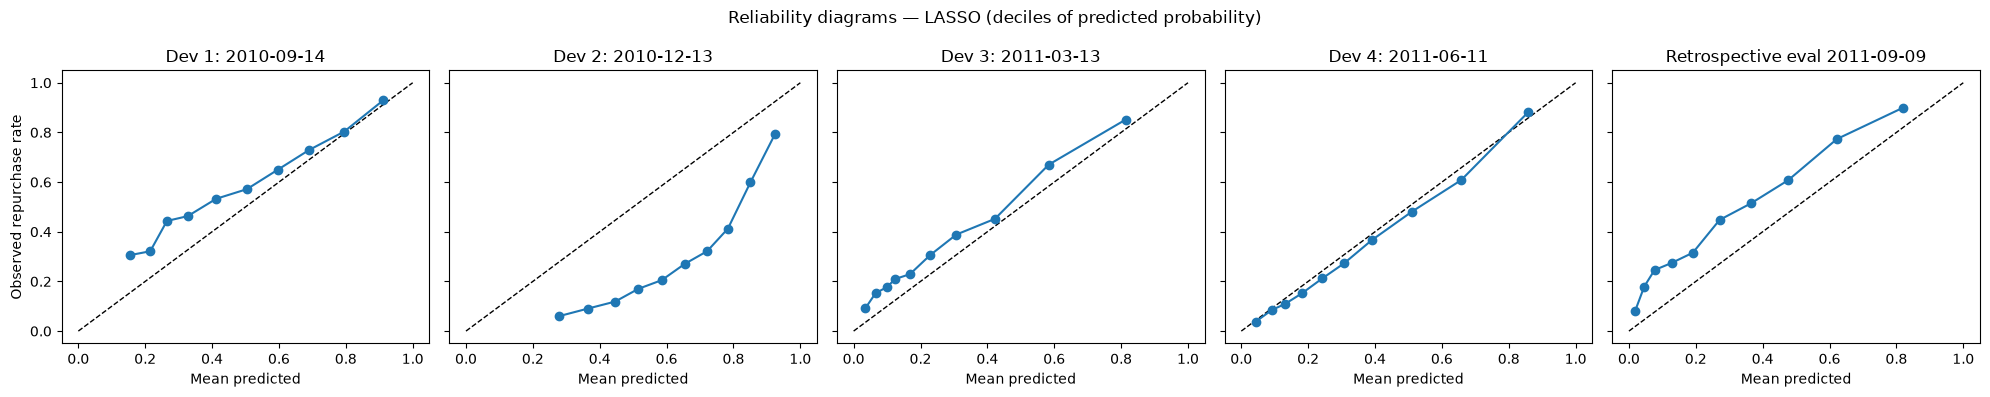

In [12]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
cal_rows = []
for ax, f in zip(axes, [1, 2, 3, 4, 'final']):
    if f == 'final':
        y_, p_ = y_ev, final_scores[SELECTED]; title = f'Retrospective eval {t_ev.date()}'
    else:
        g = dev_pred.query('fold == @f and candidate == @SELECTED'); y_, p_ = g['y'].values, g['score'].values
        title = f'Dev {f}: {DEV_FOLDS[f - 1][1].date()}'
    bins = pd.qcut(p_, 10, duplicates='drop')
    cal = pd.DataFrame({'p': p_, 'y': y_}).groupby(bins, observed=True).mean()
    ax.plot([0, 1], [0, 1], 'k--', lw=1); ax.plot(cal['p'], cal['y'], marker='o')
    ax.set_title(title); ax.set_xlabel('Mean predicted')
    a, b = calibration_int_slope(y_, p_)
    cal_rows.append({'period': title, 'mean predicted': p_.mean(), 'prevalence': y_.mean(),
                     'cal. intercept': a, 'cal. slope': b})
axes[0].set_ylabel('Observed repurchase rate')
fig.suptitle(f'Reliability diagrams — {SELECTED} (deciles of predicted probability)')
plt.tight_layout()
plt.savefig('../../reports/figures/pred_temporal_calibration.png', dpi=150, bbox_inches='tight')

g4 = dev_pred.query('fold == 4 and candidate == @SELECTED')
off = logit(np.clip(g4['score'].values, 1e-6, 1 - 1e-6))
delta = float(sm.GLM(g4['y'].values, np.ones(len(g4)), family=sm.families.Binomial(), offset=off).fit().params[0])
p_recal = expit(logit(np.clip(final_scores[SELECTED], 1e-6, 1 - 1e-6)) + delta)
recal = pd.DataFrame({'uncorrected (primary)': class_metrics(y_ev, final_scores[SELECTED], ids_ev),
                      'intercept shift from dev period 4 (assessed policy)': class_metrics(y_ev, p_recal, ids_ev)}).T
print(f'Intercept shift learned on development period 4: {delta:+.3f} on the log-odds scale')
display(pd.DataFrame(cal_rows).round(3))
recal[['Brier', 'Log-loss', 'ROC-AUC', 'Cal. intercept', 'Cal. slope', 'Mean predicted', 'prevalence']].round(4)

## D4 — Conditional positive spend: development selection

Fitted on the **repurchasers** of each training snapshot; scored on the repurchasers of the next snapshot. Spend is
heavily right-skewed, and the quantity needed downstream is the **conditional mean**, so the primary selection metric is
**development RMSE in £** (mean of the four periods, equal weight). MAE and median absolute error are reported too, but a
model is not chosen for predicting the median well.

| Candidate | Fitting inside the training snapshot |
|---|---|
| Log-OLS + Duan smearing | OLS on log(spend); predictions exp(Xβ) × mean(exp(training residuals)) |
| Gamma GLM, log link | statsmodels GLM; must converge |
| Training mean (benchmark, eligible) | Mean spend of training repurchasers |
| Training median (illustrative only) | Targets the median, a different quantity; not eligible |

Same rule as before: exclude non-converged or non-finite candidates, select the smallest unrounded mean development RMSE,
exact ties broken by the order log-OLS, Gamma, training mean.

In [13]:
SPEND_CANDS = ['Log-OLS + Duan smearing', 'Gamma GLM (log link)', 'Training mean']

def fit_spend(train):
    rep = train[train['Repurchase'] == 1]
    sc = StandardScaler().fit(rep[CONT])
    def X(d):
        Z = d[FEATURES].copy(); Z[CONT] = sc.transform(d[CONT]); return sm.add_constant(Z, has_constant='add')
    y = rep['FutureSpend'].values
    out, status = {}, {}
    ols = sm.OLS(np.log(y), X(rep)).fit()
    smear = float(np.mean(np.exp(ols.resid)))
    out['Log-OLS + Duan smearing'] = lambda d, ols=ols, smear=smear: np.exp(np.asarray(ols.predict(X(d)))) * smear
    status['Log-OLS + Duan smearing'] = 'ok'
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            gam = sm.GLM(y, X(rep), family=sm.families.Gamma(link=sm.families.links.Log())).fit(maxiter=200)
        out['Gamma GLM (log link)'] = lambda d, gam=gam: np.asarray(gam.predict(X(d)))
        status['Gamma GLM (log link)'] = 'ok' if gam.converged else 'not converged'
    except Exception as e:
        out['Gamma GLM (log link)'] = lambda d: np.full(len(d), np.nan)
        status['Gamma GLM (log link)'] = f'failed: {type(e).__name__}'
    out['Training mean'] = lambda d, m=y.mean(): np.full(len(d), m)
    out['Training median (illustrative)'] = lambda d, m=np.median(y): np.full(len(d), m)
    status['Training median (illustrative)'] = status['Training mean'] = 'ok'
    return out, status, {'smear': smear}

def spend_metrics(y, p):
    return {'N': len(y), 'RMSE': float(np.sqrt(mean_squared_error(y, p))), 'MAE': mean_absolute_error(y, p),
            'Median AE': median_absolute_error(y, p), 'Mean predicted': float(np.mean(p)), 'Mean observed': float(np.mean(y))}

cond_rows, cond_status, spend_fits = [], [], {}
for fold, (t_tr, t_va) in enumerate(DEV_FOLDS, start=1):
    fits, st, info = fit_spend(snap[t_tr])
    spend_fits[fold] = fits
    vrep = snap[t_va][snap[t_va]['Repurchase'] == 1]
    for name, f in fits.items():
        p = f(vrep)
        ok = st[name] == 'ok' and np.all(np.isfinite(p))
        cond_status.append({'fold': fold, 'candidate': name, 'status': st[name] if ok or st[name] != 'ok' else 'non-finite'})
        if ok:
            cond_rows.append({'fold': fold, 'candidate': name, **spend_metrics(vrep['FutureSpend'].values, p)})
cond_status = pd.DataFrame(cond_status)
cond_per = pd.DataFrame(cond_rows)
print(cond_status.pivot(index='candidate', columns='fold', values='status'))
cond_dev = cond_per.groupby('candidate', sort=False)[['N', 'RMSE', 'MAE', 'Median AE', 'Mean predicted', 'Mean observed']].mean()
for f in range(1, 5):
    cond_dev[f'RMSE P{f}'] = cond_per.query('fold == @f').set_index('candidate')['RMSE']
valid_spend = [c for c in SPEND_CANDS if (cond_status.query('candidate == @c')['status'] == 'ok').all()]
SPEND_SELECTED = sorted(valid_spend, key=lambda c: (cond_dev.loc[c, 'RMSE'], SPEND_CANDS.index(c)))[0]
print('\nUnrounded mean development RMSE:', {c: round(cond_dev.loc[c, 'RMSE'], 4) for c in valid_spend})
print('CONDITIONAL-SPEND MODEL SELECTED UNDER THE RMSE RULE:', SPEND_SELECTED)
cond_dev.round(1)

fold                             1   2   3   4
candidate                                     
Gamma GLM (log link)            ok  ok  ok  ok
Log-OLS + Duan smearing         ok  ok  ok  ok
Training mean                   ok  ok  ok  ok
Training median (illustrative)  ok  ok  ok  ok

Unrounded mean development RMSE: {'Log-OLS + Duan smearing': np.float64(2062.1707), 'Gamma GLM (log link)': np.float64(2073.7373), 'Training mean': np.float64(3123.4401)}
CONDITIONAL-SPEND MODEL SELECTED UNDER THE RMSE RULE: Log-OLS + Duan smearing


,N,RMSE,MAE,Median AE,Mean predicted,Mean observed,RMSE P1,RMSE P2,RMSE P3,RMSE P4
candidate,,,,,,,,,,
Log-OLS + Duan smearing,1610.5,2062.2,635.5,296.1,1092.1,1045.7,2211.1,2665.8,1361.4,2010.4
Gamma GLM (log link),1610.5,2073.7,637.5,298.0,1052.9,1045.7,2266.0,2474.2,1326.6,2228.2
Training mean,1610.5,3123.4,998.5,703.6,1057.2,1045.7,3816.5,2600.9,2659.3,3417.1
Training median (illustrative),1610.5,3169.0,795.6,279.2,472.7,1045.7,3895.7,2598.4,2711.3,3470.4


## D5 — Unconditional expected spend: development selection

With the probability model fixed (the Brier-selected model's development predictions), each conditional-spend candidate
is combined as **P(repurchase) × E[spend | repurchase]** and scored on **all** validation customers, including the £0
spenders. The selection metric is development RMSE (equal-weight mean of the four periods), MAE secondary. A constant
baseline — the training snapshot's mean spend over all customers — is reported but not eligible. The combined winner may
use a different spend component from the D4 winner; if so, that is reported, not overridden.

In [14]:
comb_rows = []
for fold, (t_tr, t_va) in enumerate(DEV_FOLDS, start=1):
    valid = snap[t_va]
    p = dev_pred.query('fold == @fold and candidate == @SELECTED').set_index('CustomerID').loc[valid['CustomerID'], 'score'].values
    yv_ = valid['FutureSpend'].values
    for name in SPEND_CANDS:
        if name in valid_spend:
            comb_rows.append({'fold': fold, 'candidate': f'P × {name}', **spend_metrics(yv_, p * spend_fits[fold][name](valid))})
    comb_rows.append({'fold': fold, 'candidate': 'Constant (training mean, all customers)',
                      **spend_metrics(yv_, np.full(len(valid), snap[t_tr]['FutureSpend'].mean()))})
comb_per = pd.DataFrame(comb_rows)
comb_dev = comb_per.groupby('candidate', sort=False)[['N', 'RMSE', 'MAE', 'Median AE', 'Mean predicted', 'Mean observed']].mean()
for f in range(1, 5):
    comb_dev[f'RMSE P{f}'] = comb_per.query('fold == @f').set_index('candidate')['RMSE']
comb_cands = [f'P × {c}' for c in valid_spend]
COMB_SELECTED = sorted(comb_cands, key=lambda c: (comb_dev.loc[c, 'RMSE'], comb_cands.index(c)))[0]
print('Unrounded mean development RMSE:', {c: round(comb_dev.loc[c, 'RMSE'], 4) for c in comb_cands})
print('COMBINED EXPECTED-SPEND SYSTEM SELECTED UNDER THE RMSE RULE:', COMB_SELECTED)
print('Same spend component as the conditional-spend winner?', COMB_SELECTED == f'P × {SPEND_SELECTED}')
comb_dev.round(1)

Unrounded mean development RMSE: {'P × Log-OLS + Duan smearing': np.float64(1377.3875), 'P × Gamma GLM (log link)': np.float64(1386.2121), 'P × Training mean': np.float64(1990.8428)}
COMBINED EXPECTED-SPEND SYSTEM SELECTED UNDER THE RMSE RULE: P × Log-OLS + Duan smearing
Same spend component as the conditional-spend winner? True


,N,RMSE,MAE,Median AE,Mean predicted,Mean observed,RMSE P1,RMSE P2,RMSE P3,RMSE P4
candidate,,,,,,,,,,
P × Log-OLS + Duan smearing,4297.0,1377.4,404.7,178.5,463.9,420.4,1756.0,1605.6,931.7,1216.3
P × Gamma GLM (log link),4297.0,1386.2,403.8,179.2,448.3,420.4,1794.1,1504.6,925.9,1320.3
P × Training mean,4297.0,1990.8,547.3,334.2,474.2,420.4,2902.4,1532.9,1587.5,1940.6
"Constant (training mean, all customers)",4297.0,2038.5,610.9,466.5,466.5,420.4,2966.5,1550.8,1643.3,1993.5


## D6 — Retrospective temporal evaluation of the locked spend systems, and influential spenders

Both locked systems are refitted on the 11 Jun 2011 snapshot and evaluated on 9 Sep 2011: the conditional model on that
period's repurchasers, the combined system on all its customers. The paired bootstrap compares each with its training-mean
baseline on the same customers.

In [15]:
fits_f, st_f, info_f = fit_spend(train_f)
print('Final spend fit status:', st_f, '| Duan smearing factor:', round(info_f['smear'], 3))
erep = evalf[evalf['Repurchase'] == 1]
cond_final = pd.DataFrame({name: spend_metrics(erep['FutureSpend'].values, f(erep)) for name, f in fits_f.items()}).T
cond_final.insert(0, 'Role', ['LOCKED' if n == SPEND_SELECTED else 'Illustrative (median target)' if 'median' in n
                              else 'Descriptive only' for n in cond_final.index])
p_ev = final_scores[SELECTED]
comb_final = {f'P × {name}': spend_metrics(evalf['FutureSpend'].values, p_ev * fits_f[name](evalf)) for name in valid_spend}
comb_final['Constant (training mean, all customers)'] = spend_metrics(
    evalf['FutureSpend'].values, np.full(len(evalf), train_f['FutureSpend'].mean()))
comb_final = pd.DataFrame(comb_final).T
comb_final.insert(0, 'Role', ['LOCKED' if n == COMB_SELECTED else 'Benchmark' if n.startswith('Constant')
                              else 'Descriptive only' for n in comb_final.index])

def boot_rmse_diff(y, a, b, B=2000, seed=SEED):
    r = np.random.default_rng(seed); d = []
    for _ in range(B):
        i = r.integers(0, len(y), len(y))
        d.append(np.sqrt(np.mean((y[i] - a[i]) ** 2)) - np.sqrt(np.mean((y[i] - b[i]) ** 2)))
    return np.percentile(d, [2.5, 97.5])

yc = erep['FutureSpend'].values
ci_c = boot_rmse_diff(yc, fits_f[SPEND_SELECTED](erep), fits_f['Training mean'](erep))
ya = evalf['FutureSpend'].values
comb_name = COMB_SELECTED.replace('P × ', '')
ci_a = boot_rmse_diff(ya, p_ev * fits_f[comb_name](evalf), np.full(len(ya), train_f['FutureSpend'].mean()))
print(f'Conditional: RMSE({SPEND_SELECTED}) − RMSE(training mean) = '
      f'{cond_final.loc[SPEND_SELECTED, "RMSE"] - cond_final.loc["Training mean", "RMSE"]:.1f}, 95% CI [{ci_c[0]:.1f}, {ci_c[1]:.1f}]')
print(f'Combined: RMSE({COMB_SELECTED}) − RMSE(constant) = '
      f'{comb_final.loc[COMB_SELECTED, "RMSE"] - comb_final.loc["Constant (training mean, all customers)", "RMSE"]:.1f}, '
      f'95% CI [{ci_a[0]:.1f}, {ci_a[1]:.1f}]')
display(cond_final.round(1))
comb_final.round(1)

Final spend fit status: {'Log-OLS + Duan smearing': 'ok', 'Gamma GLM (log link)': 'ok', 'Training median (illustrative)': 'ok', 'Training mean': 'ok'} | Duan smearing factor: 1.293
Conditional: RMSE(Log-OLS + Duan smearing) − RMSE(training mean) = -1335.8, 95% CI [-1952.0, -692.5]
Combined: RMSE(P × Log-OLS + Duan smearing) − RMSE(constant) = -884.8, 95% CI [-1292.6, -463.8]


,Role,N,RMSE,MAE,Median AE,Mean predicted,Mean observed
Log-OLS + Duan smearing,LOCKED,2278.0,3357.6,657.0,222.0,808.3,1223.0
Gamma GLM (log link),Descriptive only,2278.0,3397.5,667.8,218.2,785.8,1223.0
Training mean,Descriptive only,2278.0,4693.5,1090.0,672.5,1042.4,1223.0
Training median (illustrative),Illustrative (median target),2278.0,4756.4,954.6,274.0,430.9,1223.0


,Role,N,RMSE,MAE,Median AE,Mean predicted,Mean observed
P × Log-OLS + Duan smearing,LOCKED,5253.0,2268.7,399.8,100.6,293.9,530.3
P × Gamma GLM (log link),Descriptive only,5253.0,2296.6,406.0,104.4,286.5,530.3
P × Training mean,Descriptive only,5253.0,3098.0,503.6,187.4,314.1,530.3
"Constant (training mean, all customers)",Benchmark,5253.0,3153.5,613.1,333.9,333.9,530.3


In [16]:
# Influential large spenders: identified on the FINAL TRAINING snapshot only (Cook's distance of the Gamma GLM),
# refit without them, and evaluate on the FULL evaluation population. A sensitivity check, not the primary result.
rep_tr = train_f[train_f['Repurchase'] == 1]
sc = StandardScaler().fit(rep_tr[CONT])
def Xg(d):
    Z = d[FEATURES].copy(); Z[CONT] = sc.transform(d[CONT]); return sm.add_constant(Z, has_constant='add')
gam_f = sm.GLM(rep_tr['FutureSpend'].values, Xg(rep_tr), family=sm.families.Gamma(link=sm.families.links.Log())).fit()
cooks = pd.Series(gam_f.get_influence().cooks_distance[0], index=rep_tr.index).sort_values(ascending=False)
top = cooks.head(5).index
print('Five most influential training repurchasers (Gamma GLM):')
display(rep_tr.loc[top, ['CustomerID', 'Frequency', 'Monetary', 'FutureSpend']].assign(cooks_d=cooks.loc[top].round(3)))
gam_s = sm.GLM(rep_tr.drop(top)['FutureSpend'].values, Xg(rep_tr.drop(top)),
               family=sm.families.Gamma(link=sm.families.links.Log())).fit()
sens = pd.DataFrame({'Gamma, all training repurchasers': spend_metrics(yc, np.asarray(gam_f.predict(Xg(erep)))),
                     'Gamma, 5 most influential removed (sensitivity)': spend_metrics(yc, np.asarray(gam_s.predict(Xg(erep))))}).T
print('Top 1% of evaluation repurchasers by spend account for '
      f'{np.sort(yc)[::-1][:int(np.ceil(0.01 * len(yc)))].sum() / yc.sum():.1%} of their spend')
sens.round(1)

Five most influential training repurchasers (Gamma GLM):


,CustomerID,Frequency,Monetary,FutureSpend,cooks_d
3895,17040.0,1,13.52,449.73,7.435
4202,17386.0,1,126.35,1697.34,0.783
4771,18073.0,3,504.24,3355.58,0.529
4210,17396.0,7,1476.30,4386.30,0.261
1486,14191.0,5,919.60,1471.56,0.234


Top 1% of evaluation repurchasers by spend account for 28.4% of their spend


,N,RMSE,MAE,Median AE,Mean predicted,Mean observed
"Gamma, all training repurchasers",2278.0,3397.5,667.8,218.2,785.8,1223.0
"Gamma, 5 most influential removed (sensitivity)",2278.0,3279.1,658.3,216.4,791.1,1223.0


## D7 — Export tables

In [17]:
def export(df, name, note, fmt='.4f'):
    df.to_csv(f'{TABLES_DIR}/{name}.csv')
    with open(f'{TABLES_DIR}/{name}.md', 'w') as fh:
        out = df.astype(object).where(df.notna(), None)
        fh.write(note + '\n\n' + out.to_markdown(floatfmt=fmt, missingval='—') + '\n')

export(snapshots.set_index('origin t'), 'task5_snapshots', '**Snapshots used.** Features before t; targets in [t, t + 90 days).')
export(full_dev, 'task5_dev_classification_full',
       '**DEVELOPMENT — USED FOR SELECTION (full).** Equal-weight mean of four rolling-origin periods; '
       'Brier differences with customer-clustered bootstrap 95% CIs.', fmt='.5f')
export(compact, 'task5_dev_classification_compact',
       f'**DEVELOPMENT — USED FOR SELECTION.** Rule: smallest mean development Brier. Selected: {SELECTED}.', fmt='g')
export(final_tab, 'task5_final_classification',
       '**RETROSPECTIVE TEMPORAL EVALUATION** (trained 11 Jun 2011, evaluated 9 Sep 2011). '
       'Only the locked model and prespecified benchmarks are confirmatory; other rows are descriptive.')
export(final_unc.set_index(['benchmark', 'metric']), 'task5_final_classification_bootstrap',
       '**Paired bootstrap (2,000 replicates) of locked model minus benchmark, evaluation period.**')
export(cond_dev, 'task5_dev_conditional_spend', f'**DEVELOPMENT — conditional positive spend.** Selected: {SPEND_SELECTED}.', fmt='.1f')
export(comb_dev, 'task5_dev_expected_spend', f'**DEVELOPMENT — all-customer expected spend.** Selected: {COMB_SELECTED}.', fmt='.1f')
export(cond_final, 'task5_final_conditional_spend', '**RETROSPECTIVE TEMPORAL EVALUATION — conditional positive spend.**', fmt='.1f')
export(comb_final, 'task5_final_expected_spend', '**RETROSPECTIVE TEMPORAL EVALUATION — all-customer expected spend.**', fmt='.1f')
print('Tables written to reports/tables/')
print('Selections:', {'probability': SELECTED, 'conditional spend': SPEND_SELECTED, 'expected spend': COMB_SELECTED})

Tables written to reports/tables/
Selections: {'probability': 'LASSO', 'conditional spend': 'Log-OLS + Duan smearing', 'expected spend': 'P × Log-OLS + Duan smearing'}


## D8 — Findings

*Numbers from the current data; re-check them if notebook 00 or `src/` changes.*

**Probability model (selected under the Brier rule: LASSO).**
* Mean development Brier (four periods, equal weight): LASSO 0.20265, Ridge 0.20266, elastic net 0.20279, forward 0.20299,
  backward / best subset 0.20302, full logistic 0.20316; constant baseline 0.247. **Ridge is indistinguishable from LASSO**
  (difference +0.00001, customer-clustered 95% CI [−0.00014, +0.00016]). The other candidates are worse by 0.0001–0.0005,
  with intervals excluding zero: detectable on ~17,000 customer-periods, but about 0.1–0.25% of the Brier score, so of no
  practical consequence. LASSO is the model *selected under the declared rule*, not a clearly superior model.
* Every candidate ranks far better than the baselines (development AUC 0.778–0.779 vs 0.719 for the recency rank;
  Brier 0.203 vs 0.247 for the constant rate).
* LASSO kept 7.2 predictors on average (5 in the final refit). Recency, CancellationRate and log(Frequency) are selected
  in every fit with stable signs. TenureDays, log(Monetary), log(DistinctProducts) and AcquiredInQ4 change sign across
  fits, a symptom of their correlation (log1p(Monetary) is 99.4% explained by log1p(Frequency) and log1p(AvgBasketValue)),
  so individual coefficients should not be over-interpreted.

**Retrospective temporal evaluation (trained 11 Jun 2011, evaluated 9 Sep 2011; these outcomes had been seen before).**
* LASSO: Brier 0.2005, log-loss 0.608, AUC 0.791, AP 0.758, Precision@10% 0.899 (Lift 2.07).
* Versus the prespecified benchmarks (paired bootstrap): full logistic Brier −0.0009 [−0.0012, −0.0005], AUC +0.002
  [+0.001, +0.003]; constant rate Brier −0.058 [−0.064, −0.052]; recency rank AUC +0.030 [+0.023, +0.037] and
  Precision@10% +0.131 [+0.095, +0.169]. The ranking advantage over the simple rules is clear and survives the move to a
  later period.
* **Calibration does not survive it.** Mean predicted 0.301 against an actual 0.434; calibration intercept +0.63, slope
  0.79. Across the development periods the intercept ranges from −1.76 to +0.40: the probability *level* follows the
  training season. The assessed policy of shifting the intercept by the most recent completed period's error made the
  evaluation Brier worse (0.2005 → 0.2063), because the seasonal shift reversed. **No simple recalibration policy is
  supported by these data.**

**Spend.**
* Conditional positive spend: **Log-OLS with Duan smearing** selected (mean development RMSE £2,062; Gamma GLM £2,074;
  training mean £3,123). Gamma is close; its theoretical appeal did not translate into lower RMSE.
* Unconditional expected spend: **P(LASSO) × Log-OLS** selected (development RMSE £1,377; P × Gamma £1,386; constant
  £2,039). The same spend component wins both problems.
* Retrospective evaluation: conditional RMSE £3,358 vs £4,694 for the training mean (difference −£1,336, 95% CI
  [−£1,952, −£693]); expected-spend RMSE £2,269 vs £3,154 for the constant (−£885 [−£1,293, −£464]). Both systems
  **under-predict the level** in the Q4 evaluation window (mean £808 vs £1,223 conditional; £294 vs £530 overall).
* One training customer (1 order, £14 of history, then £450) has Cook's distance 7.4 in the Gamma GLM; removing the five
  most influential *training* customers lowers Gamma's evaluation RMSE from £3,398 to £3,279. The top 1% of evaluation
  repurchasers account for 28.4% of their spend, so RMSE is driven by a few very large buyers.

**Deployment verdict.** Ranking customers by the locked LASSO score is supported: it beats the recency rule and the
constant rate in development and in the later period. Using its probabilities, or the spend predictions, as calibrated
£ quantities is **not** supported across seasons. Any budget calculation must treat them as conditional scenario inputs,
and the effect of an offer still has to be measured experimentally (Task 6).
